# pybalmorel for Post-Processing
This notebook provide examples on how to use pybalmorel for pre-processing, post-processing and for executing Balmorel scenarios. Check the following pages:
- [Home](../README.md)
- [Pre-Processing](PreProcessing.ipynb)
- [Execution](Execution.ipynb)

In [1]:
import sys
import gams
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import gdxpds
from pandas.api.types import CategoricalDtype

# Get the absolute path of the Pybalmorel folder
pybalmorel_path = os.path.abspath("/Users/maxfavrot/Balmorel/pybalmorel_MaxF")

# Set the correct path for GAMS
gams_path = "/Library/Frameworks/GAMS.framework/Versions/48/Resources"

# Add Pybalmorel to Python's module search path
if pybalmorel_path not in sys.path:
    sys.path.insert(0, pybalmorel_path)

# Now, you can import your modules
from src.pybalmorel import MainResults
from src.pybalmorel.utils import symbol_to_df

# Set environment variables
os.environ["PATH"] = gams_path + ":" + os.environ.get("PATH", "")
os.environ["DYLD_LIBRARY_PATH"] = gams_path + ":" + os.environ.get("DYLD_LIBRARY_PATH", "")



Especially on Linux, gdxpds should be imported before pandas to avoid a library conflict. Also make sure your GAMS directory is listed in LD_LIBRARY_PATH.
Unable to load gdxcc with default GAMS directory 'None'. You may need to explicitly call gdxpds.load_gdxcc(gams_dir) before importing pandas to avoid a library conflict.


## Plotter class

In [2]:
class ThesisPlotter:
    def __init__(self,
                 style='whitegrid',
                 palette='Set2',
                 font_scale=1.2,
                 context='notebook',
                 figsize=(10, 6),
                 dpi=100):
        sns.set_theme(style=style, palette=palette, context=context)
        sns.set_context(context, font_scale=font_scale)
        self.figsize = figsize
        self.dpi = dpi
        self.palette = sns.color_palette(palette)

    def barplot(self, df, category_col, value_col, scenario_col,
                title="", unit="", ylabel=None, xlabel=None, legend_title="Scenario",
                save=False):
        """
        Create a barplot comparing scenarios across categories.

        Parameters:
        - df: DataFrame with the input data
        - category_col: column to be used on the x-axis (e.g., "Technology")
        - value_col: column with the values (e.g., "Value")
        - scenario_col: column with different scenarios (used as hue)
        - title: plot title
        - unit: unit displayed on y-axis
        - ylabel: custom y-axis label
        - xlabel: custom x-axis label
        - legend_title: title for the legend
        - save: if true, saves the figure
        """
        plt.figure(figsize=self.figsize, dpi=self.dpi)
        ax = sns.barplot(data=df,
                         x=category_col,
                         y=value_col,
                         hue=scenario_col,
                         palette=self.palette,
                         errorbar=None)

        ax.set_title(title, fontsize=14, weight='bold')
        ax.set_ylabel(ylabel if ylabel else f"{value_col} [{unit}]" if unit else value_col)
        ax.set_xlabel(xlabel if xlabel else category_col)
        ax.legend(title=legend_title)
        plt.xticks()
        plt.tight_layout()

        if save:
            plt.savefig("test.png", dpi=100)
        plt.show()

plotter = ThesisPlotter()


## Working with Outputs

This section presents examples of how to work with the outputs from Balmorel

### MainResults

The main output from Balmorel is MainResults.gdx, which may be loaded from one path (demanding different filenames, e.g., MainResults_SC1.gdx, MainResults_SC2.gdx, etc.) or several paths (which by default gives scenario names of SC1, SC2, ..., SCN format if no list of scenario_names are provided)

In [3]:
### 1.1.2 Loading several scenarios
res = MainResults(files=['MainResults_B_B.gdx', 'MainResults_B_HDISC.gdx', 'MainResults_B_excel.gdx'], paths='../master_thesis/main_results/MainResults', scenario_names=['SC1', 'SC2', 'SC3'])
res_a = MainResults(files=['all_endofmodel_B_B.gdx', 'all_endofmodel_B_HDISC.gdx', 'all_endofmodel_B_excel.gdx'], paths='../master_thesis/main_results/all_endofmodel', scenario_names=['SC1', 'SC2', 'SC3'])


/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/MainResults/MainResults_B_B.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/MainResults/MainResults_B_HDISC.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/MainResults/MainResults_B_excel.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/all_endofmodel/all_endofmodel_B_B.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/all_endofmodel/all_endofmodel_B_HDISC.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/all_endofmodel/all_endofmodel_B_excel.gdx


In [4]:
### 1.1.3 Plotting bar charts with an interactive gui
res.interactive_bar_chart()

Result type: balmorel


GridBox(children=(Dropdown(description='Table:', layout=Layout(width='80%'), options=('F_CONS_YCRA', 'F_CONS_Y…

Output()

Stack(children=(GridBox(children=(SelectMultiple(description='Scenario', index=(0,), layout=Layout(height='99%…

Output()

Output()

HBox()

Output()

Output()

Output()

# Sense check: Total costs of the system
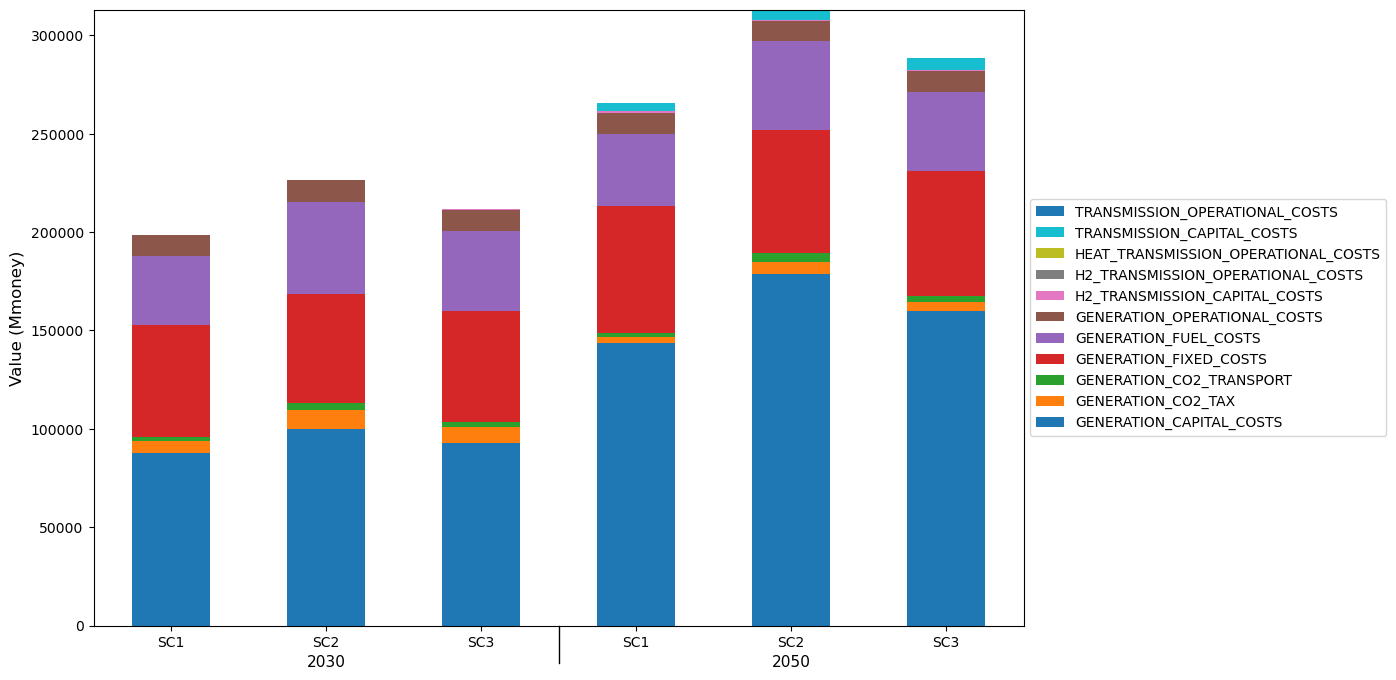

# GENERATION MIX
## Main Idea: There will be more renewable energy sources (RES) with a lower discount rate (DR)
Arguments:
- RES like wind and solar are Capital Expenditures (CAPEX)-intensive with low Operating Expenditures (OPEX), so most of the negative cashflows occur in the beginning in the project (with a high present value), and most of the positive cashflows (liked to revenues) occur later in time, so more subject to discounting. 
- A lower DR makes upfront investments more attractive, improving project economics for RES. 
- A higher DR penalizes long-term returns, making fossil plants with lower CAPEX and shorter payback periods more competitive.

As a result, higher DR favours gas/coal, while lower DR accelerates RES deployment.

"The most influential parameters for Renewable Energy Production is the discount rate" according to N. Moksnes & W. Usher in The relative importance of uncertain parameters and structural formulation for electricity systems planning in Kenya and Benin




In [11]:
# --- GET THE DATA ---
g_cap = res.get_result('G_CAP_YCRAF')
g_prod = res.get_result('PRO_YCRAGF')
eco_prod = res.get_result('ECO_G_YCRAG')

In [ ]:
#g_cap.groupby(['Scenario', 'Year']).sum().reset_index()

,Scenario,Year,Country,Region,Area,Generation,Fuel,Commodity,Technology,Category,Unit,Value
0,SC1,2030,NORWAYNORWAYNORWAYNORWAYNORWAYNORWAYNORWAYNORW...,NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1N...,NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_...,GNR_RES_WTR_NOPMP_MC-01GNR_RES_WTR_NOPMP_MC-02...,WATERWATERWATERWATERWATERWATERWATERWATERWATERW...,ELECTRICITYELECTRICITYELECTRICITYELECTRICITYEL...,HYDRO-RESERVOIRSHYDRO-RESERVOIRSHYDRO-RESERVOI...,EXOGENOUSEXOGENOUSEXOGENOUSEXOGENOUSEXOGENOUSE...,GWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGW...,3746.992952
1,SC1,2050,NORWAYNORWAYNORWAYNORWAYNORWAYNORWAYNORWAYNORW...,NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1N...,NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_...,GNR_RES_WTR_NOPMP_MC-01GNR_RES_WTR_NOPMP_MC-02...,WATERWATERWATERWATERWATERWATERWATERWATERWATERW...,ELECTRICITYELECTRICITYELECTRICITYELECTRICITYEL...,HYDRO-RESERVOIRSHYDRO-RESERVOIRSHYDRO-RESERVOI...,EXOGENOUSEXOGENOUSEXOGENOUSEXOGENOUSEXOGENOUSE...,GWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGW...,5900.905053
2,SC2,2030,NORWAYNORWAYNORWAYNORWAYNORWAYNORWAYNORWAYNORW...,NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1N...,NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_...,GNR_RES_WTR_NOPMP_MC-01GNR_RES_WTR_NOPMP_MC-02...,WATERWATERWATERWATERWATERWATERWATERWATERWATERW...,ELECTRICITYELECTRICITYELECTRICITYELECTRICITYEL...,HYDRO-RESERVOIRSHYDRO-RESERVOIRSHYDRO-RESERVOI...,EXOGENOUSEXOGENOUSEXOGENOUSEXOGENOUSEXOGENOUSE...,GWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGW...,3472.929668
3,SC2,2050,NORWAYNORWAYNORWAYNORWAYNORWAYNORWAYNORWAYNORW...,NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1N...,NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_...,GNR_RES_WTR_NOPMP_MC-01GNR_RES_WTR_NOPMP_MC-02...,WATERWATERWATERWATERWATERWATERWATERWATERWATERW...,ELECTRICITYELECTRICITYELECTRICITYELECTRICITYEL...,HYDRO-RESERVOIRSHYDRO-RESERVOIRSHYDRO-RESERVOI...,EXOGENOUSEXOGENOUSEXOGENOUSEXOGENOUSEXOGENOUSE...,GWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGW...,5668.980514
4,SC3,2030,NORWAYNORWAYNORWAYNORWAYNORWAYNORWAYNORWAYNORW...,NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1N...,NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_...,GNR_RES_WTR_NOPMP_MC-01GNR_RES_WTR_NOPMP_MC-02...,WATERWATERWATERWATERWATERWATERWATERWATERWATERW...,ELECTRICITYELECTRICITYELECTRICITYELECTRICITYEL...,HYDRO-RESERVOIRSHYDRO-RESERVOIRSHYDRO-RESERVOI...,EXOGENOUSEXOGENOUSEXOGENOUSEXOGENOUSEXOGENOUSE...,GWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGW...,3492.840301
5,SC3,2050,NORWAYNORWAYNORWAYNORWAYNORWAYNORWAYNORWAYNORW...,NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1NO1N...,NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_A1NO1_...,GNR_RES_WTR_NOPMP_MC-01GNR_RES_WTR_NOPMP_MC-02...,WATERWATERWATERWATERWATERWATERWATERWATERWATERW...,ELECTRICITYELECTRICITYELECTRICITYELECTRICITYEL...,HYDRO-RESERVOIRSHYDRO-RESERVOIRSHYDRO-RESERVOI...,EXOGENOUSEXOGENOUSEXOGENOUSEXOGENOUSEXOGENOUSE...,GWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGWGW...,5649.789008


In [65]:
# --- GENERAL FILTERS ---
Year = '2050'
Scenario = 'SC1'

# --- CREATE THE NEW LABELLING ---
default_cat = 'Others'

df_label1 = 'Fuel' #column where the labels are
df_label2 = 'FFF'
df_new_cat = 'Type' #name of the new category creates

res_fuels = ['SUN', 'WIND', 'WOODCHIPS', 'WOODWASTE', 'STRAW', 'WATER']
fossil_fuels = ['NATGAS', 'COAL']
nuclear_fuels = ['NUCLEAR']
commodity_fuels = ['ELECTRIC', 'HEAT', 'HYDROGEN']
imports = ['IMPORT_H2']

# Define the desired order
ordered_categories = [
    'RES', 'Fossil', 'Nuclear', 'Commodity', 'Imports', default_cat
]    
# Create the categorical type
cat_type = CategoricalDtype(categories=ordered_categories, ordered=True)

Costs = [
    'GENERATION_FIXED_COSTS', 'GENERATION_OPERATIONAL_COSTS',
    'GENERATION_FUEL_COSTS', 'GENERATION_CAPITAL_COSTS',
    'GENERATION_CO2_TAX', 'GENERATION_CO2_TRANSPORT'
]
Capex = ['GENERATION_CAPITAL_COSTS', 'GENERATION_FIXED_COSTS']

/var/folders/j_/mwl680ps3b1czvrppsb_jxgm0000gn/T/ipykernel_15548/4286171599.py:34: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  ax = sns.barplot(data=df,


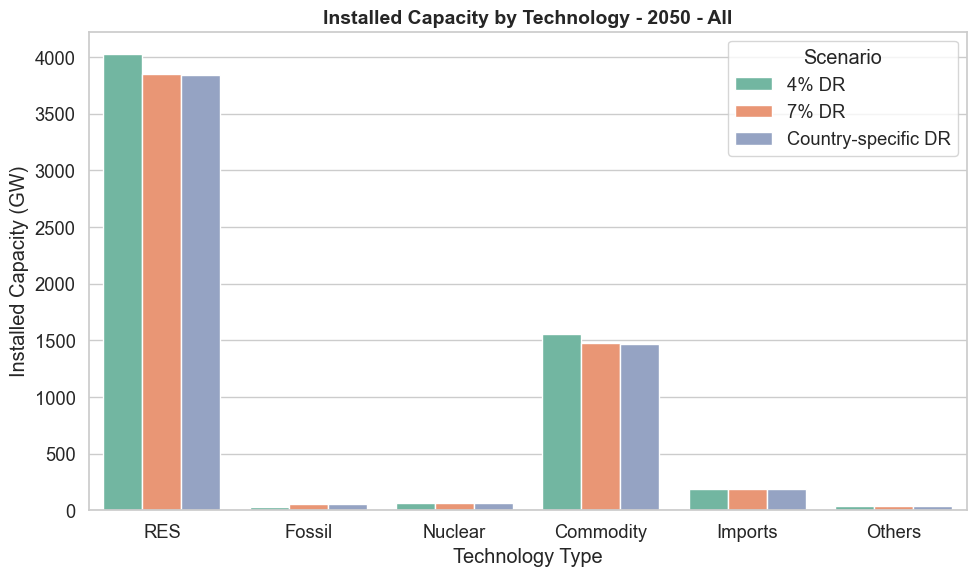

,Year,Scenario,Type,Value
18,2050,4% DR,Commodity,1556.322823
19,2050,4% DR,Fossil,32.577726
20,2050,4% DR,Imports,189.757750
21,2050,4% DR,Nuclear,63.805900
22,2050,4% DR,Others,35.093925
23,2050,4% DR,RES,4023.346929
24,2050,7% DR,Commodity,1475.424923
25,2050,7% DR,Fossil,51.421022
26,2050,7% DR,Imports,189.757750
27,2050,7% DR,Nuclear,63.805900


In [66]:
df = g_cap.copy()

# --- FILTERS ---
df[df_new_cat] = default_cat  # Default
df.loc[df[df_label1].isin(res_fuels), df_new_cat] = 'RES'
df.loc[df[df_label1].isin(fossil_fuels), df_new_cat] = 'Fossil'
df.loc[df[df_label1].isin(nuclear_fuels), df_new_cat] = 'Nuclear'
df.loc[df[df_label1].isin(commodity_fuels), df_new_cat] = 'Commodity'
df.loc[df[df_label1].isin(imports), df_new_cat] = 'Imports'

test = df



# Sum the values of unique combinaisons of year, scenario, type
detail_df = df.groupby(['Year', 'Scenario', 'Type', 'Category']).agg({'Value': 'sum'}).reset_index()
df = df.groupby(['Year', 'Scenario', 'Type']).agg({'Value': 'sum'}).reset_index()
df[df_new_cat] = df[df_new_cat].astype(cat_type)

df = df[df['Year'] == Year]


# --- RELABEL & CLEAN ---
df['Scenario'] = df['Scenario'].replace({
    'SC1': '4% DR',
    'SC2': '7% DR',
    'SC3': 'Country-specific DR'
})

# --- PLOT ---
plotter.barplot(df,
                category_col='Type',
                value_col='Value',
                scenario_col='Scenario',
                title=f"Installed Capacity by Technology - {Year} - All",
                ylabel="Installed Capacity (GW)",
                xlabel="Technology Type",
                save=True)
df
#detail_df.head(30)

In [64]:
# filter out everything that is not Other
test = test[test['Type'] == 'Others']
# sum by Technology
test = test.groupby(['Year', 'Scenario', 'Fuel']).agg({'Value': 'sum'}).reset_index()
# sort by descending order of value
test = test.sort_values(by='Value', ascending=False)
test


,Year,Scenario,Fuel,Value
67,2050,SC2,MUNIWASTE,3.559108e+01
82,2050,SC3,MUNIWASTE,3.541238e+01
52,2050,SC1,MUNIWASTE,3.489493e+01
7,2030,SC1,MUNIWASTE,2.566866e+01
37,2030,SC3,MUNIWASTE,2.436535e+01
...,...,...,...,...
75,2050,SC3,BIOGAS,-8.868774e-16
60,2050,SC2,BIOGAS,-8.868774e-16
74,2050,SC2,WOODPELLETS,-3.552714e-15
59,2050,SC1,WOODPELLETS,-3.552714e-15


### Reason 1: RES are CAPEX intensive and have lower OPEX

In [8]:
# --- FILTERS ---
g_cap = g_cap[(g_cap['Year'] == Year) & (g_cap['Scenario'] == Scenario)]
g_prod = g_prod[(g_prod['Year'] == Year) & (g_prod['Scenario'] == Scenario)]
eco_prod = eco_prod[(eco_prod['Y'] == Year) & (eco_prod['Scenario'] == Scenario)]

In [9]:
# --- GET PROD AND CAPACITY ---

# Group and rename g_cap
g_cap = (
    g_cap[['Generation', 'Value']]
    .groupby('Generation', as_index=False)
    .agg({'Value': 'sum'})
    .rename(columns={'Value': 'Capacity'})
)

# Group and rename g_prod
g_prod = (
    g_prod[['Generation', 'Value']]
    .groupby('Generation', as_index=False)
    .agg({'Value': 'sum'})
    .rename(columns={'Value': 'Production'})
)

In [10]:
# --- CLASSIFICATION & FILTERS ---

df = eco_prod.copy()

# Classify with the new cat
df[df_new_cat] = df[df_label2].map(categories).fillna(default_cat).astype(cat_type)
# Filtering out categories
df = df[~df[df_new_cat].isin(filter_out)]

# Filter only the relevant cost subcategories
df = df[df['SUBCATEGORY'].isin(Costs)]

# Label cost type
df['Cost'] = 'OPEX'  # Default
df.loc[df['SUBCATEGORY'].isin(Capex), 'Cost'] = 'CAPEX'

# --- AGGREGATION ---

# Sum cost values per tech type and cost category
df = df.groupby(['G', df_new_cat, 'Cost'], observed=True).agg({'Value': 'sum'}).reset_index()
df.rename(columns={'Value': 'Total_costs'}, inplace=True) #EURm

# Merge with g_cap and g_prod
df = df.merge(g_cap, left_on='G', right_on='Generation', how='left')
df.drop(columns=['Generation'], inplace=True)
df = df.merge(g_prod, left_on='G', right_on='Generation', how='left')
df.drop(columns=['Generation'], inplace=True)

# Get the capacity and production of each type
df_merged = df.copy()
cap_prod = df_merged.groupby(['G', df_new_cat], observed=True).agg({'Capacity': 'max', 'Production': 'max'}).reset_index()
cap_prod = cap_prod.groupby(df_new_cat, observed=True).agg({'Capacity': 'sum', 'Production': 'sum'}).reset_index()

# Group by df_new_cat and 'Cost' and sum Value,
df_grouped = df.groupby([df_new_cat, 'Cost'], observed=True).agg({'Total_costs': 'sum',}).reset_index()
df_grouped = df_grouped.merge(cap_prod, on=df_new_cat, how='left')

In [11]:
# --- UNITS ---

# Calculate the value per MW and MWh
df_grouped['Cost_per_MW'] = df_grouped['Total_costs'] / df_grouped['Capacity'] / 1000 # EURm/MW
df_grouped['Cost_per_MWh'] = df_grouped['Total_costs'] / df_grouped['Production'] # EUR/MWh
df_grouped['NCF_%'] = df_grouped['Production'] / df_grouped['Capacity'] * 1000 / 8760 * 100 # NCF in %
# Round to 2 decimal places
df_grouped = df_grouped.round({
    'Cost_per_MW': 2,
    'Cost_per_MWh': 2,
    'NCF_%': 2,
    'Capacity': 2,
    'Production': 2,
    'Total_costs': 2
})

/var/folders/j_/mwl680ps3b1czvrppsb_jxgm0000gn/T/ipykernel_58737/4286171599.py:34: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  ax = sns.barplot(data=df,


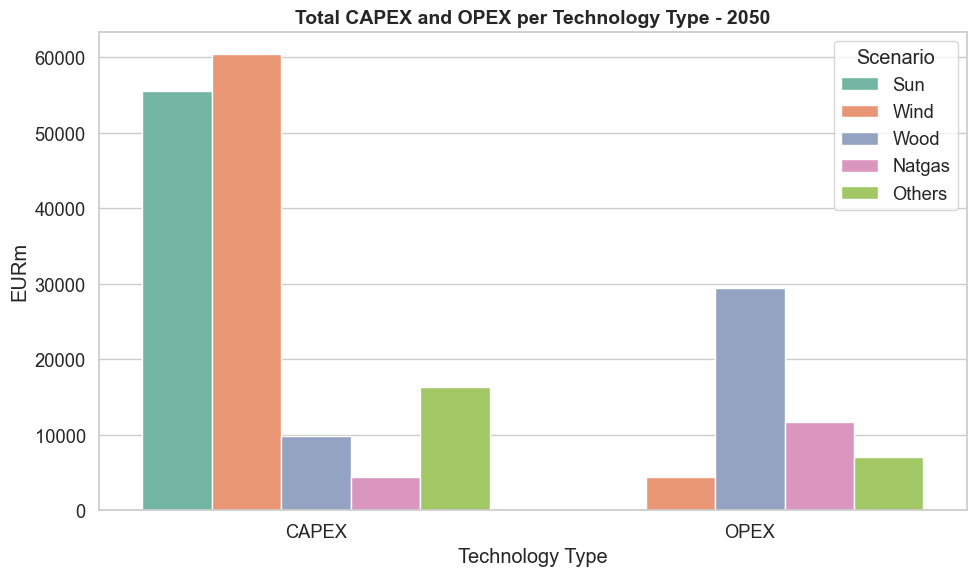

In [12]:
# --- PLOT ---

plotter.barplot(
    df_grouped,
    category_col='Cost',
    value_col='Total_costs',
    scenario_col=df_new_cat,
    title = f"Total CAPEX and OPEX per Technology Type - {Year}",
    ylabel="EURm",  # Update if you know the actual unit
    xlabel="Technology Type",
    save=True
)
#df_grouped

/var/folders/j_/mwl680ps3b1czvrppsb_jxgm0000gn/T/ipykernel_58737/4286171599.py:34: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  ax = sns.barplot(data=df,


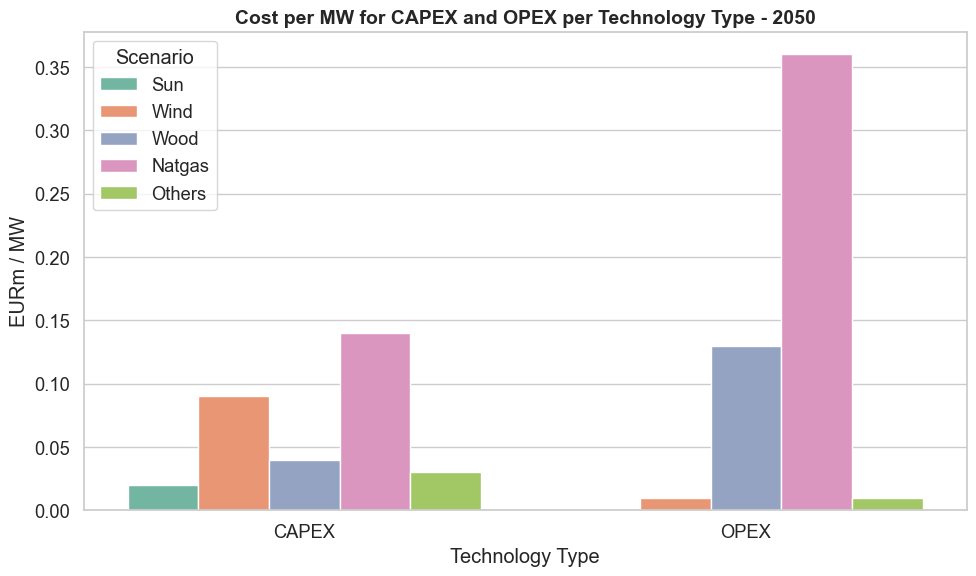

In [13]:
# --- PLOT ---

plotter.barplot(
    df_grouped,
    category_col='Cost',
    value_col='Cost_per_MW',
    scenario_col='Type',
    title=f"Cost per MW for CAPEX and OPEX per Technology Type - {Year}",
    ylabel="EURm / MW",
    xlabel="Technology Type",
    save=True
)

/var/folders/j_/mwl680ps3b1czvrppsb_jxgm0000gn/T/ipykernel_58737/4286171599.py:34: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  ax = sns.barplot(data=df,


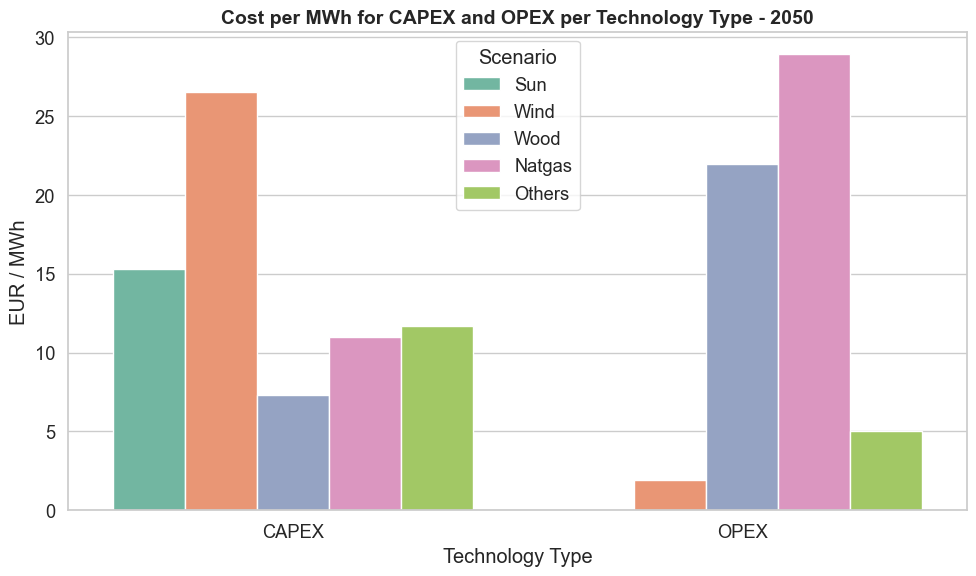

,Type,Cost,Total_costs,Capacity,Production,Cost_per_MW,Cost_per_MWh,NCF_%
0,Sun,CAPEX,55585.39,2909.51,3636.90,0.02,15.28,14.27
1,Sun,OPEX,0.06,2909.51,3636.90,0.00,0.00,14.27
2,Wind,CAPEX,60419.39,701.50,2279.88,0.09,26.50,37.10
3,Wind,OPEX,4411.30,701.50,2279.88,0.01,1.93,37.10
4,Wood,CAPEX,9824.55,224.51,1339.54,0.04,7.33,68.11
5,Wood,OPEX,29432.69,224.51,1339.54,0.13,21.97,68.11
6,Natgas,CAPEX,4445.36,32.58,403.89,0.14,11.01,141.53
7,Natgas,OPEX,11675.83,32.58,403.89,0.36,28.91,141.53
8,Others,CAPEX,16360.78,476.48,1401.68,0.03,11.67,33.58
9,Others,OPEX,7077.07,476.48,1401.68,0.01,5.05,33.58


In [14]:
# --- PLOT ---

plotter.barplot(
    df_grouped,
    category_col='Cost',
    value_col='Cost_per_MWh',
    scenario_col='Type',
    title=f"Cost per MWh for CAPEX and OPEX per Technology Type - {Year}",
    ylabel="EUR / MWh", 
    xlabel="Technology Type",
    save=True
)
df_grouped


## Wrong capacities, problem between new and existing

When looking at the total costs of the system, the solver invests way more on renewable sources than others. 
Looking at the value per MW, it is clear that RES have lower OPEX that a gas plant for example (a solar panel doesn't have any OPEX, while a gas plant needs to pay for the fuel to generate electricity). However, it is not clear that RES have higher CAPEX than gas plants.
It is only when we look at the value per MWh that it becomes clearer. Indeed, the intermitency of RES decreases their NCF (around  10% for Solar and 25% for Wind vs. 97% for Gas plants(which seems really high)), so more capacity is needed for the same amount energy produced. Looking at this metric, it appears clearly that RES have higher initial costs than fossil fuels, and lower OPEX. 
### Reason 1 is confirmed

### Questions:
- email
- why results are different from 2030 to 2050? => I think it is because I take here the overall capacity and not the new capacity added

# Installed Capacity
## Main Idea: Lower DR leads to more installed capacity in the power system.
Arguments:
- VRE requires oversizing the system to handle intermittency and meet demand reliably.
- Higher DR leads to preference for flexible, dispatchable plants (e.g., gas), reducing the need for system overcapacity.
- Therefore, total system capacity tends to be lower under high DR, and higher under low DR.



In [15]:
# --- GET THE DATA ---
g_cap = res.get_result('G_CAP_YCRAF')
g_prod = res.get_result('PRO_YCRAGF')

/var/folders/j_/mwl680ps3b1czvrppsb_jxgm0000gn/T/ipykernel_58737/4286171599.py:34: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  ax = sns.barplot(data=df,


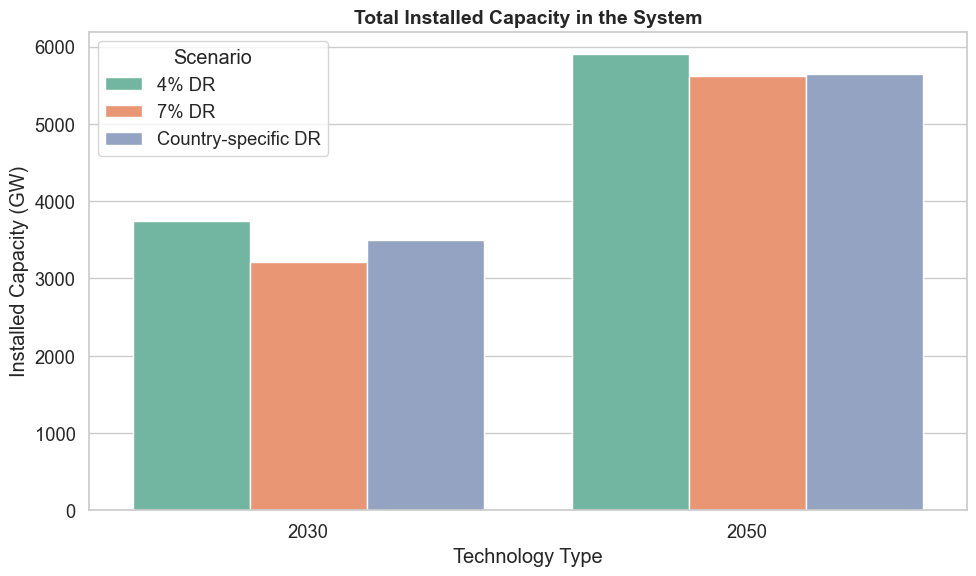

   Year             Scenario        Value
0  2030                4% DR  3746.992952
1  2030                7% DR  3210.296680
2  2030  Country-specific DR  3492.840301
3  2050                4% DR  5900.905053
4  2050                7% DR  5614.716833
5  2050  Country-specific DR  5649.789008


14.32% more capacity is needed in 2030 in the 4% DR scenario compared to the 7% DR scenario.
4.85% more capacity is needed in 2050 in the 4% DR scenario compared to the 7% DR scenario.


In [16]:
df = g_cap.copy()

# --- FILTERS ---

#df = df[df['Commodity'] == 'HYDROGEN']
# Sum the values of unique combinaisons of year, scenario, type
df = df.groupby(['Year', 'Scenario']).agg({'Value': 'sum'}).reset_index()

# --- RELABEL & CLEAN ---
df['Scenario'] = df['Scenario'].replace({
    'SC1': '4% DR',
    'SC2': '7% DR',
    'SC3': 'Country-specific DR'
})

# --- PLOT ---
plotter.barplot(df,
                category_col='Year',
                value_col='Value',
                scenario_col='Scenario',
                title="Total Installed Capacity in the System",
                ylabel="Installed Capacity (GW)",
                xlabel="Technology Type",
                save=True)
print(df)
cap_exp = df.copy()

value_4_2030 = df[(df['Scenario'] == '4% DR') & (df['Year'] == '2030')]['Value'].values[0]
value_7_2030 = df[(df['Scenario'] == '7% DR') & (df['Year'] == '2030')]['Value'].values[0]
value_4_2050 = df[(df['Scenario'] == '4% DR') & (df['Year'] == '2050')]['Value'].values[0]
value_7_2050 = df[(df['Scenario'] == '7% DR') & (df['Year'] == '2050')]['Value'].values[0]
pourcentage_2030 = (value_4_2030 - value_7_2030) / value_4_2030 * 100
pourcentage_2050 = (value_4_2050 - value_7_2050) / value_4_2050 * 100

print("\n")
print(f"{pourcentage_2030:.2f}% more capacity is needed in 2030 in the 4% DR scenario compared to the 7% DR scenario.")
print(f"{pourcentage_2050:.2f}% more capacity is needed in 2050 in the 4% DR scenario compared to the 7% DR scenario.")

lower NCF, same demand? 
other reasons?

### Reason 1: Lower NCF

/var/folders/j_/mwl680ps3b1czvrppsb_jxgm0000gn/T/ipykernel_58737/4286171599.py:34: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  ax = sns.barplot(data=df,


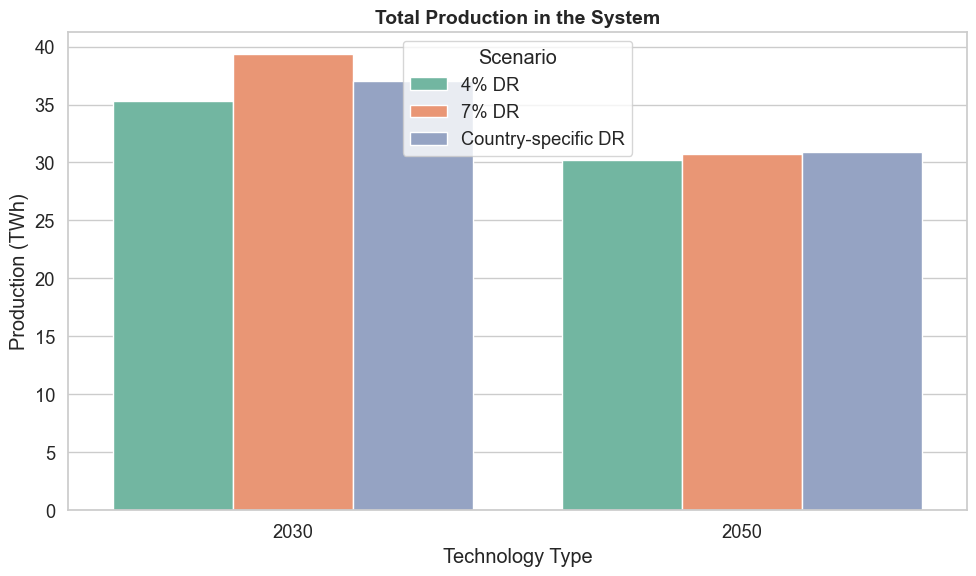

,Year,Scenario,Production,Capacity,NCF_%
0,2030,4% DR,11579.91,3746.99,35.28
1,2030,7% DR,11061.68,3210.30,39.33
2,2030,Country-specific DR,11327.15,3492.84,37.02
3,2050,4% DR,15601.84,5900.91,30.18
4,2050,7% DR,15106.46,5614.72,30.71
5,2050,Country-specific DR,15278.50,5649.79,30.87


In [17]:
df = g_prod.copy()

# --- FILTERS ---

#df = df[df['Commodity'] == 'HYDROGEN']
# Sum the values of unique combinaisons of year, scenario, type
df = df.groupby(['Year', 'Scenario']).agg({'Value': 'sum'}).reset_index()

# --- RELABEL & CLEAN ---
df['Scenario'] = df['Scenario'].replace({
    'SC1': '4% DR',
    'SC2': '7% DR',
    'SC3': 'Country-specific DR'
})

# Rename the columns
df.rename(columns={'Value': 'Production'}, inplace=True)

# merge with cap_exp
df = df.merge(cap_exp, on=['Year', 'Scenario'], how='left')
df.rename(columns={'Value': 'Capacity'}, inplace=True)
df['NCF_%'] = df['Production'] / df['Capacity'] / 8760 * 100 * 1000 # NCF in %
# Round to 2 decimal places
df = df.round({
    'Capacity': 2,
    'Production': 2,
    'NCF_%': 2
})
# --- PLOT ---
plotter.barplot(df,
                category_col='Year',
                value_col='NCF_%',
                scenario_col='Scenario',
                title="Total Production in the System",
                ylabel="Production (TWh)",
                xlabel="Technology Type",
                save=True)
df